K-NN algorithm can be used for Regression as well as for Classification but mostly it is used for the Classification Problems.

K-NN is a non-parametric algorithm, which means it does not make any assumption on underlying data.

It is also called a lazy learner algorithm.

![alt text](download.png)

In [1]:
# K-Nearest Neighbors (KNN) – Simple Explanation

# 1. KNN is a machine learning algorithm used for both classification and regression.
#    But mostly people use it for classification.

# 2. KNN does NOT learn any formula or model.
#    It is called a "lazy learner" because it just stores all the training data.

# 3. When we want to predict for a new point:
#       → KNN looks at the 'K' closest neighbors from the training data.
#       → 'K' means how many neighbors we check (like 3, 5, 7 etc.)

# 4. To find closeness, KNN uses distance formulas:
#       → Mostly Euclidean distance (normal distance between 2 points)

# 5. For classification (Yes/No, Cat/Dog):
#       → KNN checks the labels of the K nearest points.
#       → Whichever label appears more times, that becomes our prediction.
#       Example: If K = 5 and neighbors = [Dog, Cat, Dog, Dog, Cat]
#                Dog appears more → Prediction = Dog

# 6. For regression (predict numbers):
#       → KNN takes the average of the K nearest neighbors.

# 7. KNN works well when:
#       → Data is small
#       → Features are on similar scale (so we usually apply StandardScaler)

# 8. KNN becomes slow when dataset is large because it checks distance from every point.

# 9. Important hyperparameter:
#       → K value
#       → If K is too small → model becomes noisy
#       → If K is too large → model becomes too generalized

# 10. Summary:
#        - KNN stores data
#        - Finds nearest neighbors
#        - Majority vote = classification output
#        - Average = regression output

![alt text](download-1.png)


##### Second one is Become by pythagoras -- ac2 = ab2 + bc2
##### at class we give p = 1 then use First method
##### at class we give p = 2 then use Second method

### KNN classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('data/purchase.csv')

In [3]:
dataset.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
dataset.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

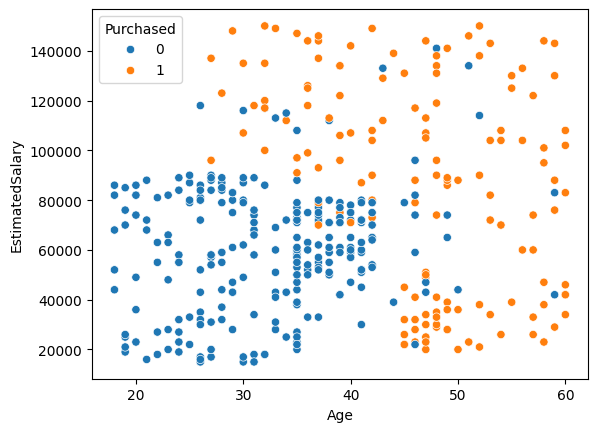

In [7]:
sns.scatterplot(x="Age", y="EstimatedSalary", hue="Purchased", data=dataset)

In [10]:
x = dataset.iloc[:,:-1]
y = dataset["Purchased"]

In [6]:
from sklearn.preprocessing import StandardScaler

In [11]:
ss = StandardScaler()
x = pd.DataFrame(ss.fit_transform(x), columns = x.columns)

In [12]:
x.head()

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train, x_test, y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [41]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
knn.score(x_test, y_test)

0.9125

In [42]:
knn.score(x_train, y_train)

0.925

In [37]:
for i in range(1, 30):
    knn1 = KNeighborsClassifier(n_neighbors=i, p=2)
    knn1.fit(x_train, y_train)
    print(f"{i}. Train: {knn1.score(x_train, y_train)}, Test: {knn1.score(x_test, y_test)}")

## 3 is best neighbor as its not biased and also provides high accuracy

1. Train: 0.996875, Test: 0.85
2. Train: 0.915625, Test: 0.8625
3. Train: 0.925, Test: 0.9125
4. Train: 0.91875, Test: 0.925
5. Train: 0.909375, Test: 0.925
6. Train: 0.909375, Test: 0.9
7. Train: 0.91875, Test: 0.9375
8. Train: 0.90625, Test: 0.925
9. Train: 0.9125, Test: 0.9375
10. Train: 0.90625, Test: 0.925
11. Train: 0.909375, Test: 0.925
12. Train: 0.9125, Test: 0.925
13. Train: 0.915625, Test: 0.925
14. Train: 0.90625, Test: 0.925
15. Train: 0.90625, Test: 0.925
16. Train: 0.9, Test: 0.925
17. Train: 0.90625, Test: 0.925
18. Train: 0.9, Test: 0.925
19. Train: 0.909375, Test: 0.925
20. Train: 0.9, Test: 0.9375
21. Train: 0.903125, Test: 0.925
22. Train: 0.9, Test: 0.9375
23. Train: 0.903125, Test: 0.9375
24. Train: 0.89375, Test: 0.9375
25. Train: 0.9, Test: 0.9375
26. Train: 0.89375, Test: 0.9375
27. Train: 0.89375, Test: 0.925
28. Train: 0.8875, Test: 0.9375
29. Train: 0.8875, Test: 0.9375


In [38]:
from mlxtend.plotting import plot_decision_regions

c:\Users\taksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


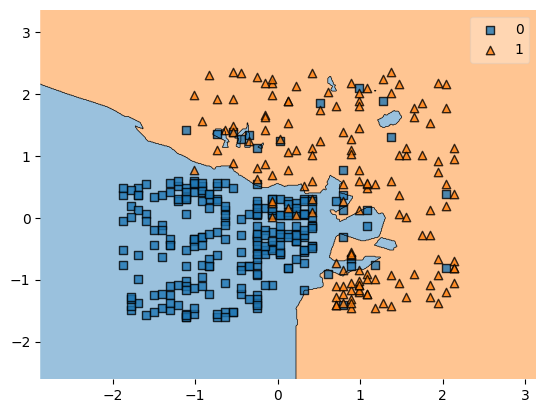

In [43]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), knn)
plt.show()

### KNN Regression

In [44]:
dataset = pd.read_csv('data/salary.csv')

In [45]:
dataset.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [46]:
dataset.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [47]:
dataset.dropna(inplace=True)

In [48]:
x = dataset[["Age", "Years of Experience"]]
y = dataset["Salary"]

In [49]:
x.head()

,Age,Years of Experience
0,32.0,5.0
1,28.0,3.0
2,45.0,15.0
3,36.0,7.0
4,52.0,20.0


In [50]:
y.head()

0     90000.0
1     65000.0
2    150000.0
3     60000.0
4    200000.0
Name: Salary, dtype: float64

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

In [53]:
from sklearn.neighbors import KNeighborsRegressor

In [54]:
knr = KNeighborsRegressor(n_neighbors=5, p=2)
knr.fit(x_train, y_train)
knr.score(x_test, y_test)

0.796938719373413

In [58]:
for i in range(1, 30):
    knr1 = KNeighborsRegressor(n_neighbors=i, p=2)
    knr1.fit(x_train, y_train)
    print(f"{i}. Train: {knr1.score(x_train, y_train)}, Test: {knr1.score(x_test, y_test)}")

## n_neighbors = values like 28 provides best output for this dataset

1. Train: 0.7009407483074286, Test: 0.6804462292616534
2. Train: 0.7531622530414495, Test: 0.7359029305555451
3. Train: 0.793578542228494, Test: 0.7744793597142543
4. Train: 0.7847861207047728, Test: 0.7697472740662556
5. Train: 0.8061815794374391, Test: 0.796938719373413
6. Train: 0.8155396362151117, Test: 0.804715294880223
7. Train: 0.8216818603649705, Test: 0.8106548709057158
8. Train: 0.8201634170967003, Test: 0.8132705998909584
9. Train: 0.8219693549274039, Test: 0.8148794844601298
10. Train: 0.8257987048202027, Test: 0.8189032229526538
11. Train: 0.828941634912483, Test: 0.8240930397504213
12. Train: 0.8318839402794345, Test: 0.8274192492859928
13. Train: 0.833438979826381, Test: 0.8273643188581457
14. Train: 0.8326289005425067, Test: 0.827040853187953
15. Train: 0.834949462071945, Test: 0.8294138474590361
16. Train: 0.8359116695540658, Test: 0.8293251851456963
17. Train: 0.8374165780500638, Test: 0.8316371391289664
18. Train: 0.8364095186056003, Test: 0.8314351828994315
19. Trai